In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report

## Memory Optimization

In [7]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(10,5)
df = sns.load_dataset('titanic')
df.to_csv('titanic_real_data.csv',index=False)

initial_memory=df.memory_usage(deep=True).sum()/1024
print(f"Initial memory is ---> {initial_memory:.2f} MB")

df['pclass']=df['pclass'].astype('int8')
df['sibsp']=df['sibsp'].astype('int8')
df['parch']=df['parch'].astype('int8')

df['sex']=df['sex'].astype('category')
df['embarked']=df['embarked'].astype('category')
df['who']=df['who'].astype('category')

optimized_memory=df.memory_usage(deep=True).sum()/1024
saved_memory=((initial_memory-optimized_memory)/initial_memory)*100

print(f'Memory usage after enhancing ---> {optimized_memory:.2f} KB')
print(f'Memory saving percantge ---> {saved_memory:2f}%')


Initial memory is ---> 278.87 MB
Memory usage after enhancing ---> 127.80 KB
Memory saving percantge ---> 54.173845%


## Data Cleaning

In [9]:
df['age']=df['age'].fillna(df['age'].median())
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])


## Feature Engineering

In [ ]:
df['family_size']=df['sibsp']+df['parch']+1
df['alone']=(df['family_size']==1).astype(int)
df['male']=(df['sex']=='male').astype(int)

## Machine Learning (ML Baseline)

In [23]:
features = ['pclass', 'age', 'fare', 'family_size', 'alone', 'male']
x=df[features]
y=df['survived']

x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

clf=RandomForestClassifier(n_estimators=100,random_state=42)
clf.fit(x_train,y_train)

y_pred=clf.predict(x_test)
acc=accuracy_score(y_pred,y_test)

print(f"Passenger Survival Prediction Accuracy ---> {acc*100:.2f}%")

Passenger Survival Prediction Accuracy ---> 80.45%


## Exploratory Data Analysis

C:\Users\Ayatullah\AppData\Local\Temp\ipykernel_24024\4186108171.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='sex',y='survived',palette='Set2',ax=axes[0])


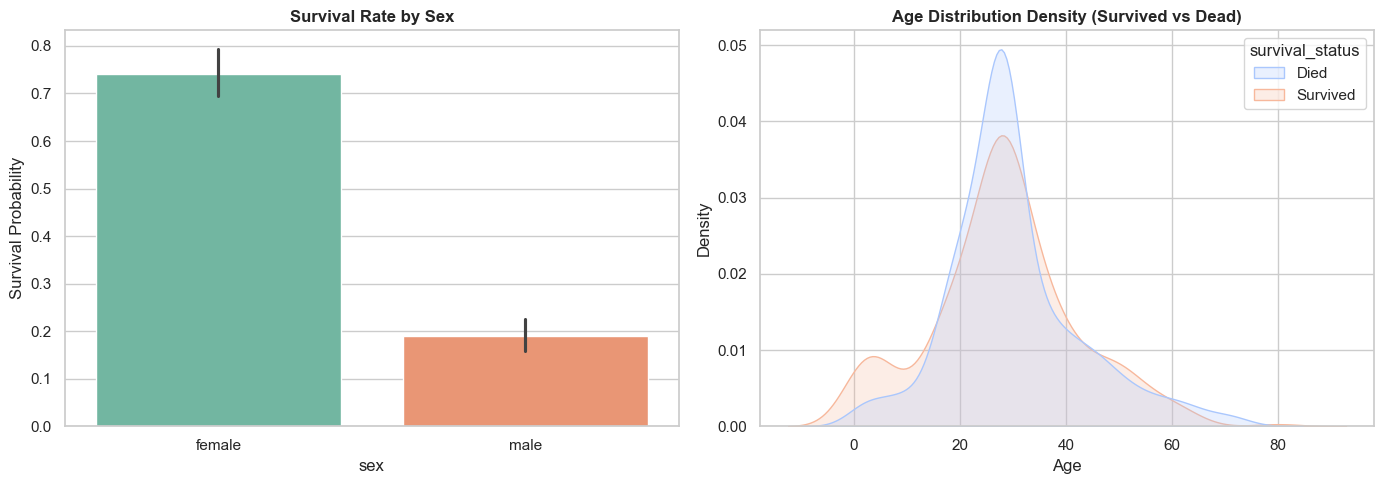

In [19]:
df['survival_status'] = df['survived'].map({0: 'Died', 1: 'Survived'})

fig,axes=plt.subplots(1,2,figsize=(14,5))

sns.barplot(data=df,x='sex',y='survived',palette='Set2',ax=axes[0])
axes[0].set_title('Survival Rate by Sex',fontsize=12,fontweight='bold')
axes[0].set_ylabel('Survival Probability')

sns.kdeplot(
    data=df, 
    x='age', 
    hue='survival_status',
    common_norm=False, 
    fill=True, 
    palette='coolwarm', 
    ax=axes[1]
)
axes[1].set_title('Age Distribution Density (Survived vs Dead)',fontsize=12,fontweight='bold')
axes[1].set_xlabel('Age')

plt.savefig('Real-World Data Pipeline & Memory Optimization Engine.png')

plt.tight_layout()
plt.show()
